Assume you need 3kWh/day for each person, 2kWh/day if >1000msnm (IPSE)
Community MG costs 1930kUSD/MWp

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.038, 0.188, 0.421,
       0.676, 0.883, 0.988, 0.962, 0.812, 0.579, 0.324, 0.117, 0.012,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

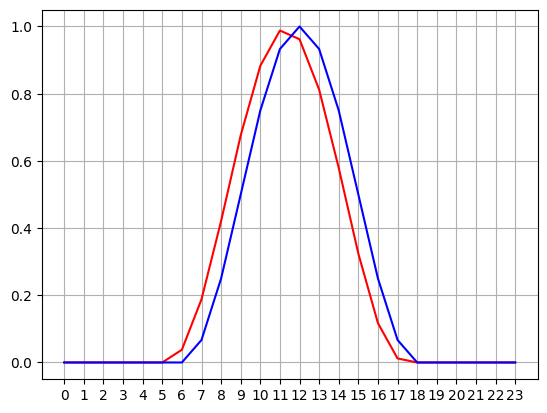

In [ ]:
import numpy as np

hours = list(range(24))
peak_demand_CE_kW=100
curve_CE_pu = np.array([0.261, 0.261, 0.261, 0.261, 0.261, 0.696, 0.652, 0.348, 0.348,0.522, 0.565, 0.609, 0.739, 0.696, 0.609, 0.565, 0.739, 0.87 ,0.957, 1.   , 1.   , 1.   , 0.87 , 0.435])
curve_CE_kW=curve_CE_pu*peak_demand_CE_kW
#Integral=bout 15 Peak Demands*h
day_demand_CE_kWh=sum(curve_CE_pu) #kWh/day
#perfect 6 kWh/day curve
solar_irradiance_kWm2 = np.array([]) 
sunrise=5.8
for h in hours:
    if sunrise <= h <= sunrise+12:
        # Simple sine curve to model the daylight hours (normalized)
        ll=100
        generation = np.round(sum([(np.sin(np.pi * (t/ll+h - sunrise) / 12) ** 2) for t in range(ll)])/ll,3)
    else:
        generation = 0
    solar_irradiance_kWm2=np.append(solar_irradiance_kWm2,generation)  
#need ~2peakdemands of peakPVgen
PV_m2_or_kWp=250 #it is also KWp
solar_generation_kW=PV_m2_or_kWp*solar_irradiance_kWm2
#storage
BESS_CE_kWh=800
BESS_CE_kW=100 #8h autonomy
#Total project cost 450.000 USD ~1900MCOP
CE_usdperkwh=450000/(15*365*6*PV_m2_or_kWp)*3 #random ass factor
CE_usdperkwh
import matplotlib.pyplot as plt
plt.plot(solar_irradiance_kWm2,'r-')
curve_solar=[0., 0., 0., 0., 0., 0., 0., 0.067, 0.25 ,0.5, 0.75, 0.933, 1., 0.933, 0.75, 0.5, 0.25, 0.067,0., 0., 0.,0., 0., 0.]
plt.plot(curve_solar,'b-')
plt.xticks(range(24))
plt.grid(which='both')
solar_irradiance_kWm2

### Simplest deterministic ED, 3 gens with (dynamic, eg solar) power bounds and load balance 

$\min_{p_{i,t}} \sum_t^{T}\sum_i^{N_G} p^{G}_{i,t} c^{G}_g$

$\text{s.t.}~ \sum_i^{N_G} p^{G}_{t,i} = L_t ~ \forall t\in[T]$

$\text{s.t.}~ p^{Min}_i \leq p^{G}_{i,t} \leq p^{Max}_{i,t}$

In [2]:
## Simplest deterministic ED
Ngen=3
T=24
p_gmax_kw=np.array([2800,1000,3000])
p_gmin_kw=np.array([0,0,0])
c_gen_copkwh=np.array([100,160,600])
dem_peak_kw=2000
dem_curve=np.array([0.857, 0.847, 0.796, 0.753, 0.745, 0.714, 0.673, 0.714, 0.765,0.786, 0.837, 0.878, 0.878, 0.959, 1., 0.98 , 0.959, 0.918,0.939, 0.959, 0.98 , 0.994, 0.959, 0.898])
curve_gen1=np.array([0., 0., 0., 0., 0., 0., 0., 0.067, 0.25 ,0.5, 0.75, 0.933, 1., 0.933, 0.75, 0.5, 0.25, 0.067,0., 0., 0.,0., 0., 0.])
curve_nocurve=np.ones((24))
p_gmax_kw_mtx=np.vstack((curve_gen1,curve_nocurve,curve_nocurve))


import gurobipy as gp
from gurobipy import GRB
import numpy as np

m=gp.Model("ED1")

pG=m.addMVar(shape=(Ngen,T),name="pG",vtype=GRB.CONTINUOUS)

fobj=gp.LinExpr()
for i in range(T):
    fobj+=c_gen_copkwh @ pG[:,i]
m.setObjective(fobj, GRB.MINIMIZE)

m.addConstrs((pG[:,i].sum()==dem_peak_kw*dem_curve[i] for i in range(T)),"loadbalance")
m.addConstrs((pG[:,i]<=p_gmax_kw_mtx[:,i]*p_gmax_kw for i in range(T)),"pmax")
m.addConstrs((pG[:,i]>=p_gmin_kw for i in range(T)),"pmin")
m.optimize()


Restricted license - for non-production use only - expires 2025-11-24
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: AMD Ryzen 7 7840HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 168 rows, 72 columns and 216 nonzeros
Model fingerprint: 0x2a31c28b
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e+02, 6e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+02, 3e+03]
Presolve removed 165 rows and 63 columns
Presolve time: 0.00s
Presolved: 3 rows, 9 columns, 9 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.0285000e+07   1.952500e+02   0.000000e+00      0s
       3    1.0378720e+07   0.000000e+00   0.000000e+00      0s

Solved in 3 iterations and 0.00 seconds (0.00 work units)
Optimal objective  1.037872000e+07


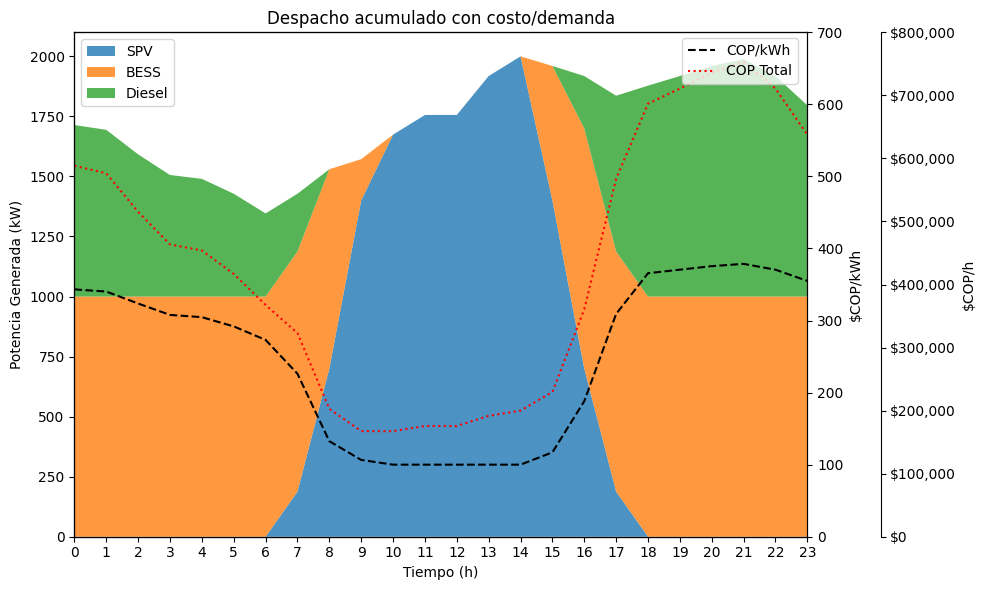

In [ ]:
## plot

pG_res=pG.X
genlabels=['SPV', 'BESS', 'Diesel'] ## Gen 2 is a fake BESS
cG_mtx=np.transpose(np.tile(c_gen_copkwh,(T,1)))
cG_res=pG_res*cG_mtx
cop_total=np.sum(cG_res,axis=0)
cop_kwh=cop_total/(dem_curve*dem_peak_kw)

import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 23, T)

# Graficar áreas apiladas
fig, ax1 = plt.subplots(figsize=(10,6))
ax1.stackplot(x, pG_res, labels=genlabels, alpha=0.8)
ax1.set_ylabel('Potencia Generada (kW)')
ax1.set_xlabel('Tiempo (h)')
ax1.set_xticks(x)
ax1.set_xlim((0,23))
#ax1.set_ylim((0,1000))
ax1.legend(loc='upper left')

# Primer eje derecho (COP/kWh)
ax2 = ax1.twinx()
ax2.plot(x, cop_kwh, color='black', linestyle='--', label='COP/kWh')
ax2.set_ylabel('$COP/kWh')
ax2.set_ylim((0,700))
ax2.tick_params(axis='y', labelcolor='black')

# Segundo eje derecho (COP totales)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('axes', 1.1))  # Mueve el eje un poco más a la derecha
ax3.plot(x, cop_total, color='red', linestyle=':', label='COP Total')
ax3.set_ylabel('$COP/h')
ax3.set_ylim((0,800000))
ax3.tick_params(axis='y', labelcolor='black')
ax3.yaxis.set_major_formatter('${x:,.0f}')

h1, l1 = ax2.get_legend_handles_labels()
h2, l2 = ax3.get_legend_handles_labels()
fig.legend(h1 + h2, l1 + l2, loc='upper right',
           bbox_to_anchor=(0.81, 0.94),  # coordenadas dentro del gráfico
           frameon=True)

plt.title("Despacho acumulado con costo/demanda")
plt.tight_layout()
plt.show()


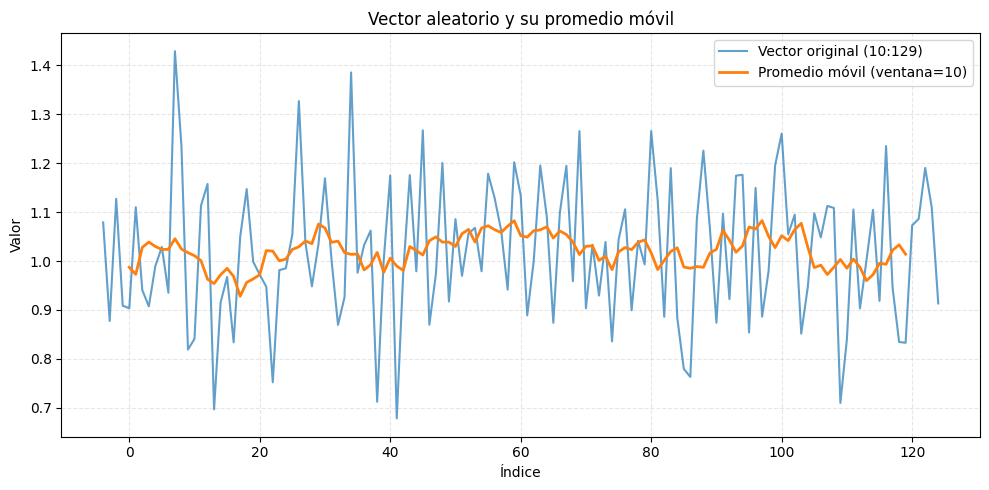

In [25]:
### PROMEDIO MOVIL

import numpy as np
import matplotlib.pyplot as plt

# Generar vector random
# np.random.seed(0)
mu = 1
sigma = 0.15
n = 120 + 9  # 129 datos

# Generar y recortar
raw = np.random.normal(mu, sigma, size=n)
low = mu - 4 * sigma
high = mu + 4 * sigma
raw_clipped = np.clip(raw, low, high)

# Calcular promedio móvil con ventana 10
window = 10
mov_avg = np.convolve(raw_clipped, np.ones(window)/window, mode='valid')  # 120 datos

# Graficar
fig, ax = plt.subplots(figsize=(10, 5))

# Plot del vector original entre posiciones 10 y 129 (indices 10:130)
ax.plot(np.arange(-9, 120)+window//2, raw_clipped[:], label='Vector original (10:129)', alpha=0.7)

# Plot del promedio móvil (120 puntos)
ax.plot(np.arange(0, 120), mov_avg[:], label='Promedio móvil (ventana=10)', linewidth=2)

# Plot 10 blocks avg point
# ax.plot(np.arange(0,120,10)+5, [np.average(mov_avg[i*10:(i+1)*10]) for i in range(12)],label="10 Block Avg movavg")
# # # Plot 10 blocks avg point
# ax.plot(np.arange(0,120,10)+5, [np.average(raw_clipped[i*10:(i+1)*10]) for i in range(12)],label="10 Block Avg raw")

ax.set_title("Vector aleatorio y su promedio móvil")
ax.set_xlabel("Índice")
ax.set_ylabel("Valor")
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()



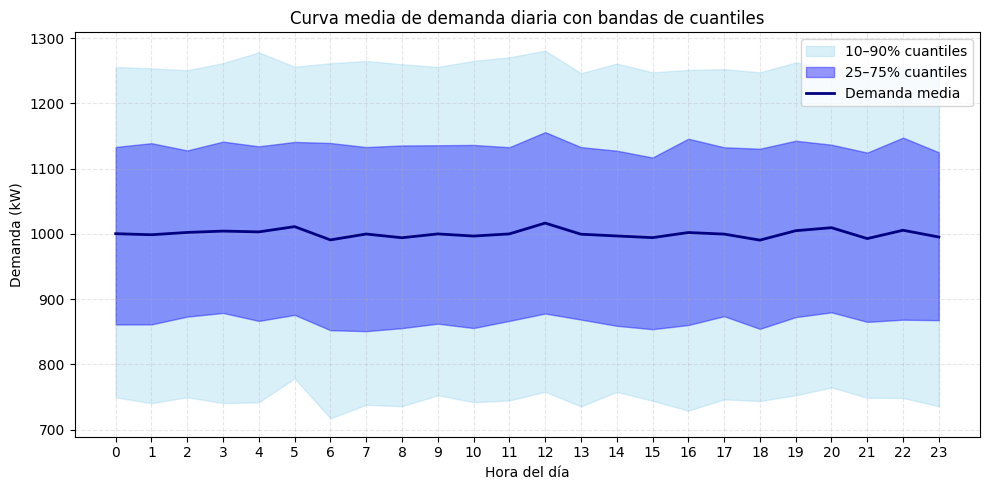

In [5]:
### PLOTEANDO BANDAS DE CUANTILES

import numpy as np
import matplotlib.pyplot as plt

# Simulación ejemplo
np.random.seed(42)
D = np.random.normal(loc=1000, scale=200, size=(1000, 24))

# Eje x (horas del día)
horas = np.arange(24)

# Estadísticas
media = np.mean(D, axis=0)
p10 = np.percentile(D, 10, axis=0)
p25 = np.percentile(D, 25, axis=0)
p75 = np.percentile(D, 75, axis=0)
p90 = np.percentile(D, 90, axis=0)

# Plot
plt.figure(figsize=(10, 5))

# Banda 10–90%
plt.fill_between(horas, p10, p90, color='skyblue', alpha=0.3, label='10–90% cuantiles')

# Banda 25–75%
plt.fill_between(horas, p25, p75, color='blue', alpha=0.4, label='25–75% cuantiles')

# Curva media
plt.plot(horas, media, color='navy', label='Demanda media', linewidth=2)

# Estética
plt.title("Curva media de demanda diaria con bandas de cuantiles")
plt.xlabel("Hora del día")
plt.ylabel("Demanda (kW)")
plt.xticks(horas)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
a=np.arange(1,10)
b=np.arange(5,14)
np.sum([a,b],axis=0)
1//30

0

In [53]:
def bla(inputlist):
    for i in inputlist:
        yield i+i,i**2
a=[(x,y) for x,y in bla([1,2,3,4,5])]
print(a)
xx,yy=zip(*[(x,y) for x,y in bla([1,2,3,4,5])])
print(type(xx))
print(yy)

[(2, 1), (4, 4), (6, 9), (8, 16), (10, 25)]
<class 'tuple'>
(1, 4, 9, 16, 25)


In [21]:
np.array(np.array(np.array([1,2,3])*[3,2,4]))

array([ 3,  4, 12])

In [59]:
np.arange(0,5,1)+[2]

array([2, 3, 4, 5, 6])

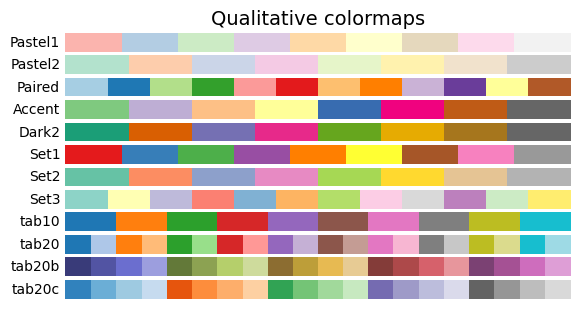

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib as mpl

cmaps = {}

gradient = np.linspace(0, 1, 256)
gradient = np.vstack((gradient, gradient))


def plot_color_gradients(category, cmap_list):
    # Create figure and adjust figure height to number of colormaps
    nrows = len(cmap_list)
    figh = 0.35 + 0.15 + (nrows + (nrows - 1) * 0.1) * 0.22
    fig, axs = plt.subplots(nrows=nrows + 1, figsize=(6.4, figh))
    fig.subplots_adjust(top=1 - 0.35 / figh, bottom=0.15 / figh,
                        left=0.2, right=0.99)
    axs[0].set_title(f'{category} colormaps', fontsize=14)

    for ax, name in zip(axs, cmap_list):
        ax.imshow(gradient, aspect='auto', cmap=mpl.colormaps[name])
        ax.text(-0.01, 0.5, name, va='center', ha='right', fontsize=10,
                transform=ax.transAxes)

    # Turn off *all* ticks & spines, not just the ones with colormaps.
    for ax in axs:
        ax.set_axis_off()

    # Save colormap list for later.
    cmaps[category] = cmap_list


plot_color_gradients('Qualitative',
                     ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2',
                      'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b',
                      'tab20c'])

In [ ]:
A=np.array([[1,2],[5,6]])
B=np.array([4,5])
np.concatenate((A,np.array([B])),axis=0)

array([[1, 2],
       [5, 6],
       [4, 5]])

In [15]:
def fx(xxx,a=1,b=2,c=3):
    print(f"a :{a}, b:{b}, c:{c}, xxx={xxx}")
params={'a':3,'c':5,'d':6}
# fx(**params) # fails

# Very cool filtered kwargs unpacking
import inspect
validkwargs=inspect.signature(fx).parameters.keys()
subparams={k:params[k] for k in params & validkwargs}
fx('asddf',**subparams)
type(validkwargs&params)
set(params)
print(subparams)
{k:val for k,val in params.items() if k in validkwargs}


a :3, b:2, c:5, xxx=asddf
{'c': 5, 'a': 3}


{'a': 3, 'c': 5}

In [2]:
a={}
a|={'x4':2}
print(f"a: {a}")

a: {'x4': 2}


In [9]:
res=(23432,5435,652738,3345,632)
print("dgfsdgd: {} asfads: {}, sdgfs: {}, asdf: {}, asdf: {}, asdf: {}".format(3+4,*res))

dgfsdgd: 7 asfads: 23432, sdgfs: 5435, asdf: 652738, asdf: 3345, asdf: 632


In [ ]:
import scipy.stats as stats 
stats.beta

TypeError: _parse_args() missing 2 required positional arguments: 'a' and 'b'

In [99]:
{5,3,8,'a'} | {'a',4,3}

{3, 4, 5, 8, 'a'}

In [106]:
x=[1,4,5]
for xi in x:
    print(max(xi,2))

2
4
5


In [ ]:
# You know nested functions?

def make_multiplier(factor):
    def multiplier(n):
        return n * factor
    return multiplier

times_two = make_multiplier(2)
print(times_two(3))
# Output: 6

# Well decorators are even cooler bc you can define handy function wrappers
def my_decorator(func):
    #decorator must return a function handle, and uses the function it's decorating
    def wrapper():
        print('Something is happening before the function is called.')
        func()
        print('Something is happening after the function is called.')
    return wrapper

@my_decorator
def say_hello():
    print('Hello!')
say_hello()

# You can also give it args
def repeat_decorator(times):
    def decorator(func):
        def wrapper(*args, **kwargs):
            for _ in range(times):
                func(*args, **kwargs)
        return wrapper
    return decorator

@repeat_decorator(3)
def say_hello(name):
    print(f'Hello, {name}!')

say_hello('John')


# Managing resources?? Use this one simple trick noob programmers hate!!1!!12!

# Classic version: I can create an x-resource-context-manager class to call using with x(*args) as _ 
# with x(*args) as y does x.__init__(), x().__enter__(), stuff with y, then x().__exit__()

# Easier version, with decorators:
from contextlib import contextmanager

def acquire_resource():
    return None
def release_resource(res):
    pass

@contextmanager
def managed_resource(arg=1,*args, **kwds):
    # Enter method
    resource = acquire_resource(*args, **kwds)
    try:
        yield resource
    finally:
        # Exit method
        release_resource(resource)

# And now i can:
with managed_resource(arg=0) as res:
    # Do stuff with res
    print(res)
    pass
    # Automatically close resource

# Or even cooler, make not just quick context managers
import time
@contextmanager
def timed():
    start_time = time.time()
    yield # returns... a generator? well it does
    end_time = time.time()
    print(f'Time elapsed: {end_time - start_time:.2f} seconds')

# to be used for measuring functions like this
def wait():
    time.sleep(0.1)

with timed():
    wait()

# but also quick decorators, to be used like this
@timed()
def wait():
    time.sleep(0.1)

wait()





6
Something is happening before the function is called.
Hello!
Something is happening after the function is called.
Hello, John!
Hello, John!
Hello, John!
None
Time elapsed: 0.10 seconds
Time elapsed: 0.10 seconds


In [57]:
# a=[4,2]
a.append(4)
a

[4, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]

In [ ]:
x=np.zeros(3)
y=np.array(x)
y+=4
print(x)
print(y)

[0. 0. 0.]
[4. 4. 4.]


In [ ]:
np.maximum

In [1]:
'spv'=='spvsdf'or'fsdf'

'fsdf'

In [214]:
import logging
logger = logging.getLogger(__name__)
FORMAT = "[%(filename)2s:%(lineno)2s - %(funcName)2s()] %(message)s"
logging.basicConfig(format=FORMAT)
logger.setLevel(logging.DEBUG)
# Use as follows
logger.debug("Hello world!")

def myf():
    logger.debug("dfghj")
    return 0

myf()

[241881680.py: 7 - <module>()] Hello world!
[241881680.py:10 - myf()] dfghj


0

In [ ]:
epsilon_range = np.append(np.concatenate(
    [np.arange(1, 10)*10.0**(i) for i in range(-4, 0)]), 1.0)
epsilon_range

array([1.e-04, 2.e-04, 3.e-04, 4.e-04, 5.e-04, 6.e-04, 7.e-04, 8.e-04,
       9.e-04, 1.e-03, 2.e-03, 3.e-03, 4.e-03, 5.e-03, 6.e-03, 7.e-03,
       8.e-03, 9.e-03, 1.e-02, 2.e-02, 3.e-02, 4.e-02, 5.e-02, 6.e-02,
       7.e-02, 8.e-02, 9.e-02, 1.e-01, 2.e-01, 3.e-01, 4.e-01, 5.e-01,
       6.e-01, 7.e-01, 8.e-01, 9.e-01, 1.e+00])

In [ ]:
from datetime import datetime
import time
datetime.strftime(datetime.today(),"%b\%d_%H%M")

'Jul09_1358'

In [5]:
import numpy as np
x=np.array([4,7,1])
x+=[3,1,2]
x

array([7, 8, 3])

In [10]:
class gfhjk:
    a=20
class sf(gfhjk):
    b="d"
    c=gfhjk.a
    # c=a # dont work
x=sf()
x.c

20

In [28]:
import numpy as np
import gurobipy as gp
from gurobipy import GRB
M=gp.Model("asdf")
x=M.addMVar(shape=(2,3),name="xx",vtype=GRB.CONTINUOUS,lb=-GRB.INFINITY)
ct=M.addConstr(x==np.zeros((2,3)),name='ctrr')
M.update()
ct.RHS=np.zeros((2,3))
ct.RHS.shape


(2, 3)

In [ ]:
import time
N=int(1e7)
x = [{"a": i} for i in range(N)]
y = [{"a": i} for i in range(N)]

class Test:
    def __init__(self):
        self.x = x

    def assign(self, x):
        self.x = x

    def assign_check(self, x):
        if self.x == x:
            return
        self.x = x

t = Test()

start = time.time()
t.assign(y)
print("Assign only:", time.time() - start)

start = time.time()
t.assign_check(y)
print("Assign with check:", time.time() - start)


Assign only: 0.0
Assign with check: 0.04756307601928711


In [1]:
def func1(a,b=2,c=3,**kwargs):
    print(kwargs)
    print(func2(**kwargs))
    return None

def func2(d=3,f=2,**kwargs):
    print(kwargs)
    return 0

func1(a=1,d=4,f=5,l=1,c=5)

# You literally never need to filter kwargs when downpassing(?)
# EDkwargs={'plot_ED','EDplotstyle','stackalpha','grb_verbose','BESS_SOE_init'}
# kwargs={k:val for k,val in kwargs.items() if k in EDkwargs}
            

{'d': 4, 'f': 5, 'l': 1}
{'l': 1}
0


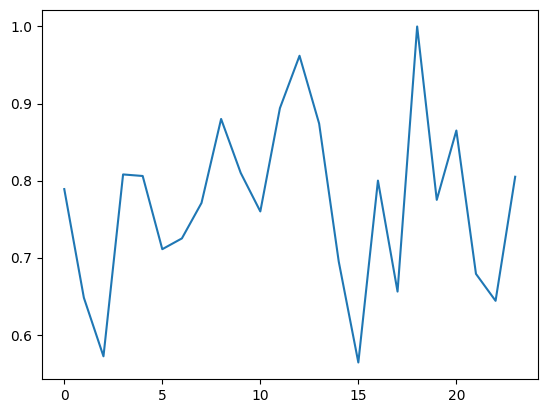

In [119]:
import numpy as np
import matplotlib.pyplot as plt
x=np.random.random(24)/2+0.6
x=np.round(x/max(x),3)
plt.plot(x)

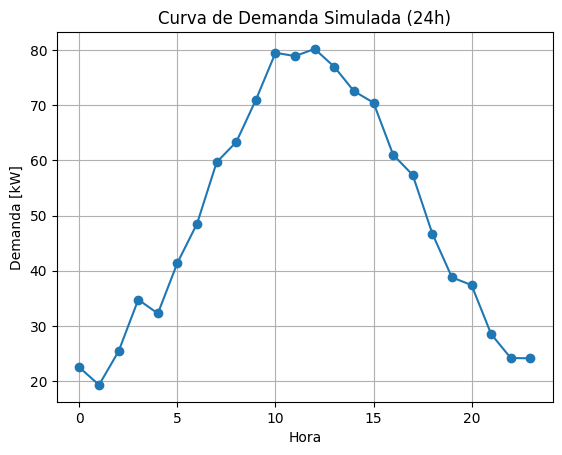

array([0.55, 0.45, 0.45, 0.63, 0.62, 0.63, 0.68, 0.77, 0.85, 0.86, 0.89,
       0.96, 1.  , 0.93, 0.82, 0.74, 0.8 , 0.7 , 0.81, 0.64, 0.68, 0.53,
       0.48, 0.56])

In [120]:
import numpy as np
import matplotlib.pyplot as plt

# Generar vector de 24 puntos
horas = np.arange(24)

# Simular una curva de demanda en MW (o kW)
# Ejemplo: base + sinusoide + pequeño ruido
base = 50
amplitud = 30
ruido = np.random.normal(0, 2, 24)

# Pico en la tarde (hora 18)
demanda = base + amplitud * np.sin((horas - 6) / 24 * 2 * np.pi) + ruido
demanda = np.clip(demanda, 0, None)

# Mostrar
plt.plot(horas, demanda, marker='o')
plt.title("Curva de Demanda Simulada (24h)")
plt.xlabel("Hora")
plt.ylabel("Demanda [kW]")
plt.grid(True)
plt.show()

y=demanda/max(demanda)
z=(x+y)/2
np.round(z/max(z),2)



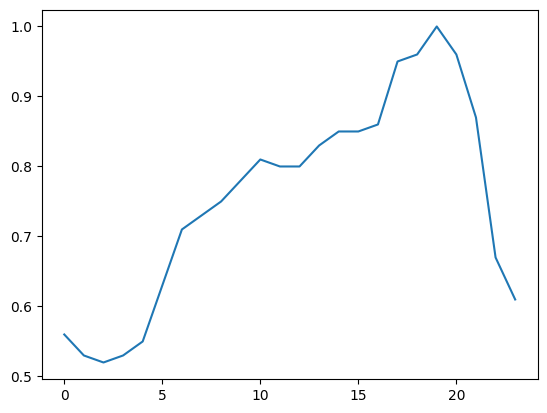

In [201]:
plt.plot([0.56, 0.53, 0.52, 0.53, 0.55, 0.63, 0.71, 0.73, 0.75, 0.78, 0.81,
       0.8, 0.8  , 0.83, 0.85, 0.85, 0.86, 0.95, 0.96, 1 ,0.96, 0.87,
       0.67,0.61])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar datos
np.random.seed(0)
data1 = np.random.normal(loc=1, scale=0.3, size=1000)
data2 = np.random.normal(loc=2, scale=0.5, size=1000)

# Calcular medias
mean1 = np.mean(data1)
mean2 = np.mean(data2)

# Graficar histogramas
plt.figure(figsize=(8,5))
plt.hist(data1, bins=30, alpha=0.6, label='Normal(1, 0.3)', color='skyblue', edgecolor='k')
plt.hist(data2, bins=30, alpha=0.6, label='Normal(2, 0.5)', color='salmon', edgecolor='k')

# Líneas verticales en las medias
plt.axvline(mean1, color='blue', linestyle='--', linewidth=2)
plt.axvline(mean2, color='red', linestyle='--', linewidth=2)
plt.text(mean1, plt.ylim()[1]*0.9, f"Media 1: {mean1:.2f}", color='blue', ha='right')
plt.text(mean2, plt.ylim()[1]*0.8, f"Media 2: {mean2:.2f}", color='red', ha='right')

plt.xlabel('Valor')
plt.ylabel('Frecuencia')
plt.title('Histogramas de dos distribuciones normales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [2]:
import math, gurobipy as gp
from gurobipy import GRB

# ------------------ Datos base ------------------
buses = [1,2,3]
slack = 1
lines = [(1,2),(2,3),(1,3)]
Sbase_MW = 100.0

# r,x (pu) razonables y simétricos
r_pu, x_pu = 0.50, 1.50   # => G=0.20, B=0.60
r = {e:r_pu for e in lines}
x = {e:x_pu for e in lines}
bsh = {e:0.0 for e in lines}

G, B = {}, {}
for (i,j) in lines:
    den = r[(i,j)]**2 + x[(i,j)]**2
    G[(i,j)] = r[(i,j)]/den           # >0
    B[(i,j)] = x[(i,j)]/den           # >0

# Cargas (pu)
Pd = {1:0.06, 2:0.08, 3:0.05}
Qd = {1:0.02, 2:0.03, 3:0.02}

# Generación (pu) y costos
Pg_min, Pg_max = {1:0.0, 2:0.0, 3:0.0}, {1:0.20, 2:0.20, 3:0.0}
Qg_min, Qg_max = {1:-0.20,2:-0.20,3:0.0}, {1:0.20,2:0.20,3:0.0}
cost = {1:20.0, 2:25.0, 3:0.0}

# Límites térmicos por línea (pu)
Smax = {(i,j):0.04 for (i,j) in lines}

Vmin, Vmax = 0.95, 1.05
theta_max_deg = 20.0
theta_max = math.radians(theta_max_deg)

# PWL para cos(Δθ): nodos en -20,-10,0,10,20 [deg]
phi = [-theta_max, -theta_max/2, 0.0, theta_max/2, theta_max]
tan_A = [-math.sin(pk) for pk in phi]
tan_B = [ math.cos(pk) + math.sin(pk)*pk for pk in phi]
sec_s, sec_t = [], []
for k in range(len(phi)-1):
    p0, p1 = phi[k], phi[k+1]
    s = (math.cos(p1)-math.cos(p0))/(p1-p0)
    t = math.cos(p0) - s*p0
    sec_s.append(s); sec_t.append(t)

# ------------------ Modelo ------------------
m = gp.Model("LPAC_3bus_fix_signs")


V     = m.addVars(buses, lb=Vmin, ub=Vmax, name="V")
theta = m.addVars(buses, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="theta")
u     = m.addVars(buses, lb=0.0, ub=GRB.INFINITY, name="u")     # ~ V^2

Pg = m.addVars(buses, lb=[Pg_min[i] for i in buses], ub=[Pg_max[i] for i in buses], name="Pg")
Qg = m.addVars(buses, lb=[Qg_min[i] for i in buses], ub=[Qg_max[i] for i in buses], name="Qg")

dth = m.addVars(lines, lb=-theta_max, ub=theta_max, name="dtheta")
cij = m.addVars(lines, lb=math.cos(theta_max), ub=1.0, name="c")  # cos approx

arcs = [(i,j) for (i,j) in lines] + [(j,i) for (i,j) in lines]
Pij = m.addVars(arcs, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Pij")
Qij = m.addVars(arcs, lb=-GRB.INFINITY, ub=GRB.INFINITY, name="Qij")
for (i,j) in lines:
    S = Smax[(i,j)]
    Pij[(i,j)].LB = -S; Pij[(i,j)].UB =  S
    Pij[(j,i)].LB = -S; Pij[(j,i)].UB =  S
    Qij[(i,j)].LB = -S; Qij[(i,j)].UB =  S
    Qij[(j,i)].LB = -S; Qij[(j,i)].UB =  S


# Slack de ángulo
m.addConstr(theta[slack] == 0.0, name="ref")

# Δθ
for (i,j) in lines:
    m.addConstr(dth[(i,j)] == theta[i]-theta[j], name=f"dtheta_{i}_{j}")

# u ≈ V^2 (expansión en Vbar=1): u_i = 2*V_i - 1
for i in buses:
    m.addConstr(u[i] == 2.0*V[i] - 1.0, name=f"u_lin_{i}")

# Envolvente PWL de cos(Δθ)
for (i,j) in lines:
    for pk in phi:
        # c_ij <= cos(pk) - sin(pk)*(Δθ - pk)  =  -sin(pk)*Δθ + cos(pk) + sin(pk)*pk
        m.addConstr(cij[(i,j)] <= -math.sin(pk)*dth[(i,j)] + (math.cos(pk) + math.sin(pk)*pk),
                    name=f"cos_tan_only_{i}_{j}_{int(math.degrees(pk))}")
    # Lower box bound global: c >= cos(theta_max)
    m.addConstr(cij[(i,j)] >= math.cos(theta_max), name=f"c_lower_{i}_{j}")
    
# WARM START COEFF
Vbar={1:0.97, 2:0.97, 3:0.97}
k = {(i,j): Vbar[i]*Vbar[j] for (i,j) in lines}
# ---- Flujos LPAC con G>0, B>0 ----
# P_ij = G*u_i - G*cij - B*dθ
# Q_ij = -(B + bsh/2)*u_i + B*cij - G*dθ
Pij_ct, Qij_ct, Pji_ct, Qji_ct = {}, {}, {}, {}
for (i,j) in lines:
    Gij, Bij, bshij = G[(i,j)], B[(i,j)], bsh[(i,j)]
    # i->j
    ij,ji=f"f{i}t{j}",f"f{j}t{i}"
    print(ij)
    Pij_ct[ij]=m.addConstr(Pij[(i,j)] == Gij*u[i] - Gij*k[i,j]*cij[(i,j)] - Bij*k[i,j]*dth[(i,j)], name=f"P{i}{j}")
    Qij_ct[ij]=m.addConstr(Qij[(i,j)] == -(Bij + 0.5*bshij)*u[i] + k[i,j]*Bij*cij[(i,j)] - k[i,j]*Gij*dth[(i,j)], name=f"Q{i}{j}")
    # j->i (usa el mismo cij y dth con signo opuesto)
    Pji_ct[ji]=m.addConstr(Pij[(j,i)] == Gij*u[j] - Gij*k[i,j]*cij[(i,j)] + Bij*k[i,j]*dth[(i,j)], name=f"P{j}{i}")
    Qji_ct[ji]=m.addConstr(Qij[(j,i)] == -(Bij + 0.5*bshij)*u[j] +k[i,j]* Bij*cij[(i,j)] + k[i,j]*Gij*dth[(i,j)], name=f"Q{j}{i}")

# Octágono térmico
rt2 = math.sqrt(2.0)
Poly = {}
SquareSlack = {}
for (i,j) in lines:
    S = Smax[(i,j)]
    for a in [(i,j),(j,i)]:
        SquareSlack[(a,"Pmax")]=m.addVar(lb=0.0, ub=GRB.INFINITY, name=f"slack_{a[0]}{a[1]}_Pmax")
        SquareSlack[(a,"Pmin")]=m.addVar(lb=0.0, ub=GRB.INFINITY, name=f"slack_{a[0]}{a[1]}_Pmin")
        SquareSlack[(a,"Qmax")]=m.addVar(lb=0.0, ub=GRB.INFINITY, name=f"slack_{a[0]}{a[1]}_Qmax")
        SquareSlack[(a,"Qmin")]=m.addVar(lb=0.0, ub=GRB.INFINITY, name=f"slack_{a[0]}{a[1]}_Qmin")
        
        Poly[(a,'Pmax')]=m.addConstr( Pij[a]+SquareSlack[(a,"Pmax")] ==  S)
        Poly[(a,'Pmin')]=m.addConstr(-Pij[a]+SquareSlack[(a,"Pmin")] ==  S)
        Poly[(a,'Qmax')]=m.addConstr( Qij[a]+SquareSlack[(a,"Qmax")] ==  S)
        Poly[(a,'Qmin')]=m.addConstr(-Qij[a]+SquareSlack[(a,"Qmin")] ==  S)
        
        Poly[(a,'pPpQ')]=m.addConstr(  Pij[a] +  Qij[a] <=  rt2*S)
        Poly[(a,'mPmQ')]=m.addConstr( -Pij[a] -  Qij[a] <=  rt2*S)
        Poly[(a,'pPmQ')]=m.addConstr(  Pij[a] -  Qij[a] <=  rt2*S)
        Poly[(a,'mPpQ')]=m.addConstr( -Pij[a] +  Qij[a] <=  rt2*S)

# Pérdidas no negativas
for (i,j) in lines:
    Gij = G[i,j]
    m.addConstr(Gij*(u[i] + u[j]) - 2*Gij*k[i,j]*cij[i,j] >= 0, name=f"loss_ge0_{i}_{j}")

# Balances nodales
balP, balQ = {}, {}
for i in buses:
    neigh = [j for (ii,j) in arcs if ii == i]
    balP[i] = m.addConstr(Pg[i] - Pd[i] - gp.quicksum(Pij[(i,j)] for j in neigh) == 0, name=f"balP_{i}")
    balQ[i] = m.addConstr(Qg[i] - Qd[i] - gp.quicksum(Qij[(i,j)] for j in neigh) == 0, name=f"balQ_{i}")

# Objetivo
m.setObjective(gp.quicksum(cost[i]*Sbase_MW*Pg[i] for i in buses), GRB.MINIMIZE)

m.Params.OutputFlag = 1
m.optimize()

if m.status == GRB.OPTIMAL:
    print("\n=== ÓPTIMO ===")
    for i in buses:
        print(f"Bus {i}: V={V[i].X:.4f} pu, θ={math.degrees(theta[i].X):+.3f}°, "
              f"Pg={Pg[i].X*Sbase_MW:6.2f} MW, Qg={Qg[i].X*Sbase_MW:6.2f} MVAr")
    print("\nFlujos [MW/MVAr]:")
    for (i,j) in lines:
        print(f"{i}->{j}: P={Pij[(i,j)].X*Sbase_MW:+7.2f}, Q={Qij[(i,j)].X*Sbase_MW:+7.2f}   "
              f"{j}->{i}: P={Pij[(j,i)].X*Sbase_MW:+7.2f}, Q={Qij[(j,i)].X*Sbase_MW:+7.2f}")
    print("\nLMPs ($/MWh) = duales de balP:")
    for i in buses:
        print(f"λ[{i}] = {balP[i].Pi/Sbase_MW: .4f}")
        
    for key, con in Poly.items():
    # imprime solo caras realmente activas
        if abs(con.Slack) < 1e-8:
            print(key, "dual=", con.Pi/Sbase_MW, "slack=", con.Slack)
else:
    print("Status:", m.status)
    try:
        m.computeIIS()
        m.write("lpac_3bus_fix.ilp")
        print("IIS guardado en lpac_3bus_fix.ilp")
    except gp.GurobiError:
        pass


f1t2
f2t3
f1t3
Gurobi Optimizer version 11.0.2 build v11.0.2rc0 (win64 - Windows 11+.0 (26100.2))

CPU model: AMD Ryzen 7 7840HS w/ Radeon 780M Graphics, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 94 rows, 57 columns and 217 nonzeros
Model fingerprint: 0xb65c909e
Coefficient statistics:
  Matrix range     [2e-01, 2e+00]
  Objective range  [2e+03, 3e+03]
  Bounds range     [4e-02, 1e+00]
  RHS range        [2e-02, 1e+00]
Presolve removed 70 rows and 40 columns
Presolve time: 0.00s
Presolved: 24 rows, 23 columns, 96 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    1.0683682e+02   8.828173e-01   0.000000e+00      0s
      12    4.1000000e+02   0.000000e+00   0.000000e+00      0s

Solved in 12 iterations and 0.01 seconds (0.00 work units)
Optimal objective  4.100000000e+02

=== ÓPTIMO ===
Bus 1: V=0.9756 pu, θ=+0.000°, Pg= 13.00 MW, Qg=  1.94 MVAr
Bus 2: V=0

In [8]:
import numpy as np  
N=10
a=np.zeros((N,4))
for i in range(N):
    x=np.random.random(4)
    a[i,:]=x
a
a[2,:]

array([0.66218433, 0.95653819, 0.32702964, 0.72847548])

In [10]:
agents=[i+1 for i in range(5)]
neighbors={1:[2,3],2:[1,4],3:[1,4,5],4:[2,3],5:[3]}
undirected_edges = set()
for i in agents:
    for j in neighbors.get(i, []):
        if i != j:
            undirected_edges.add(tuple(sorted((i, j))))
undirected_edges


{(1, 2), (1, 3), (2, 4), (3, 4), (3, 5)}

In [19]:
x=np.random.random((3,10))*10
# print(x)
xq=np.percentile(x,100-90,axis=1)
print(xq)
np.vstack([xq for _ in range(10)]).T.shape
[3 for _ in range(24)]

[1.00572356 0.51519496 5.07888964]


[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

In [32]:
import math, gurobipy as gp
from gurobipy import GRB
m = gp.Model("sdgfh")
Xtop=np.ones((4,10))
X=m.addMVar(shape=(4,10),name="X",vtype=GRB.CONTINUOUS,lb=-GRB.INFINITY)
Y=m.addMVar(shape=(4,10),name="Y",vtype=GRB.CONTINUOUS,lb=-GRB.INFINITY)
# m.addConstrs((X[:,i]==Xtop[:,i] for i in range(10)),"ctrs")
m.addConstr(X<=Xtop,"ctrs")
z=gp.GenExpr()
z=X+Y
z
cc=m.addConstr(z<=np.ones((4,10))*10,"ctrs2")
cc.RHS=np.ones((4,10))*5
cc
z.sum(axis=0)+np.ones(10)
# 0.3*np.ones(4).T@X
# X[2,:]*Y[2,:]
a=m.addVar()
m.addConstr(a==gp.norm(X[0,:],GRB.INFINITY))

<gurobi.GenConstr *Awaiting Model Update*>

In [11]:
import numpy as np
hasattr(np.sum([45,645,8,43]),"__len__")

False